# 第 7 章 OpenCV 影像模糊、銳化與馬賽克

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 7-2-4 程式範例：比較平均、高斯、中值模糊的效果

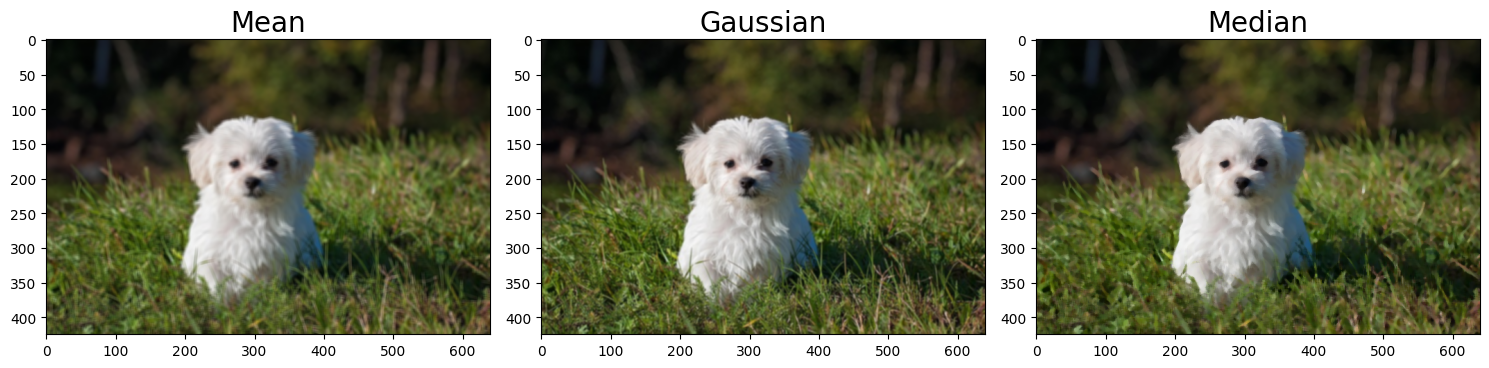

In [2]:
# 讀取原始影像
img = cv2.imread('sample/dog.jpg')

# 套用 5x5 卷積核的平均模糊
mean_blur = cv2.blur(img, (5, 5))
# 套用 5x5 卷積核的高斯模糊，將 sigmaX 設為 0 讓 OpenCV 自動計算標準差
gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)
# 套用 5x5 滑動視窗的中值模糊（注意：此處參數為整數）
median_blur = cv2.medianBlur(img, 5)

opencv_tools.show_img_by_matplotlib_1x3(
    "Mean", mean_blur,
    "Gaussian", gaussian_blur,
    "Median", median_blur
)

### 7-2-5 程式範例：比較不同濾波器大小的效果

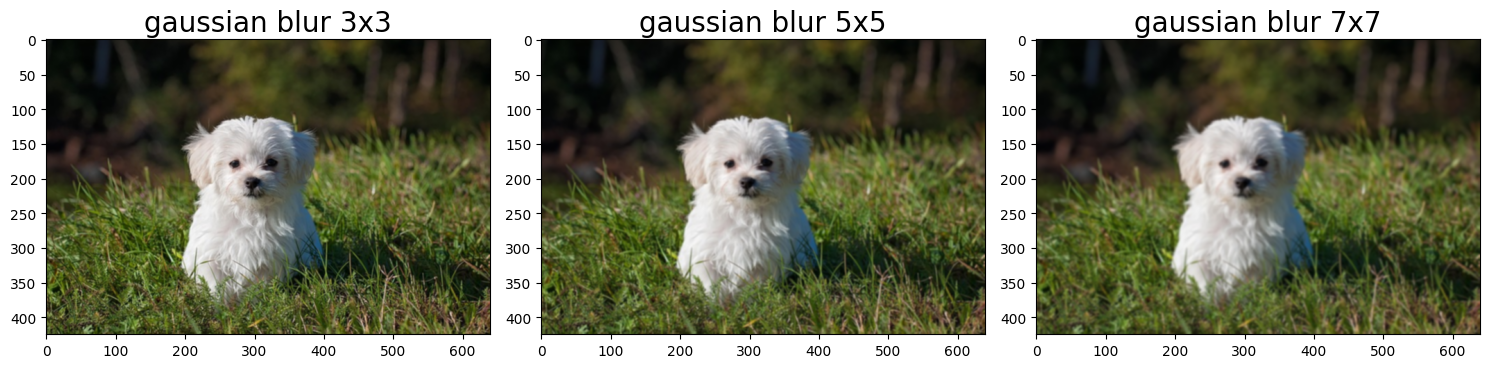

In [3]:
# 讀取原始影像
img = cv2.imread('sample/dog.jpg')

# 套用 3x3 卷積核的高斯模糊，sigmaX=0 讓 OpenCV 自動計算
gaussian_blur_3x3 = cv2.GaussianBlur(img, (3, 3), 0)
# 套用 5x5 卷積核的高斯模糊，sigmaX=0 讓 OpenCV 自動計算
gaussian_blur_5x5 = cv2.GaussianBlur(img, (5, 5), 0)
# 套用 7x7 卷積核的高斯模糊，sigmaX=0 讓 OpenCV 自動計算
gaussian_blur_7x7 = cv2.GaussianBlur(img, (7, 7), 0)

opencv_tools.show_img_by_matplotlib_1x3(
    "gaussian blur 3x3", gaussian_blur_3x3,
    "gaussian blur 5x5", gaussian_blur_5x5,
    "gaussian blur 7x7", gaussian_blur_7x7
)

### 7-3-2 程式範例：影像銳化

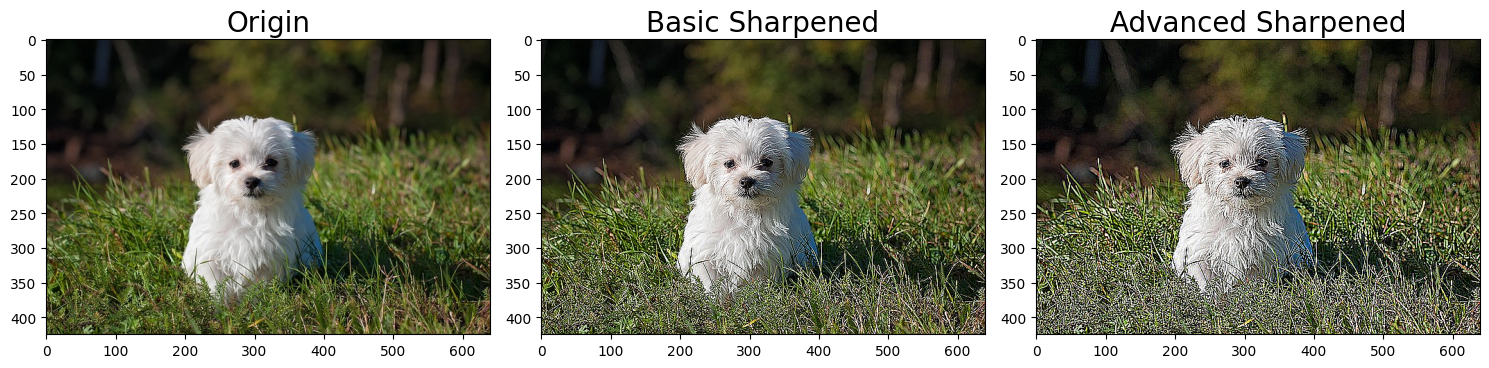

In [4]:
# 讀取影像
img = cv2.imread('sample/dog.jpg')

# 定義一個基本的 3x3 銳化核
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# 使用 filter2D 應用銳化核
sharpened_img = cv2.filter2D(img, -1, sharpen_kernel)

# 定義一個加強銳化效果的 3x3 銳化核
advanced_sharpen_kernel = np.array([
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
])

# 使用 filter2D 應用進階銳化核
advanced_sharpened_img = cv2.filter2D(img, -1, advanced_sharpen_kernel)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Origin', img,
    'Basic Sharpened', sharpened_img,
    'Advanced Sharpened', advanced_sharpened_img
)


### 7-3-4 程式範例：透過「模糊」實現銳化

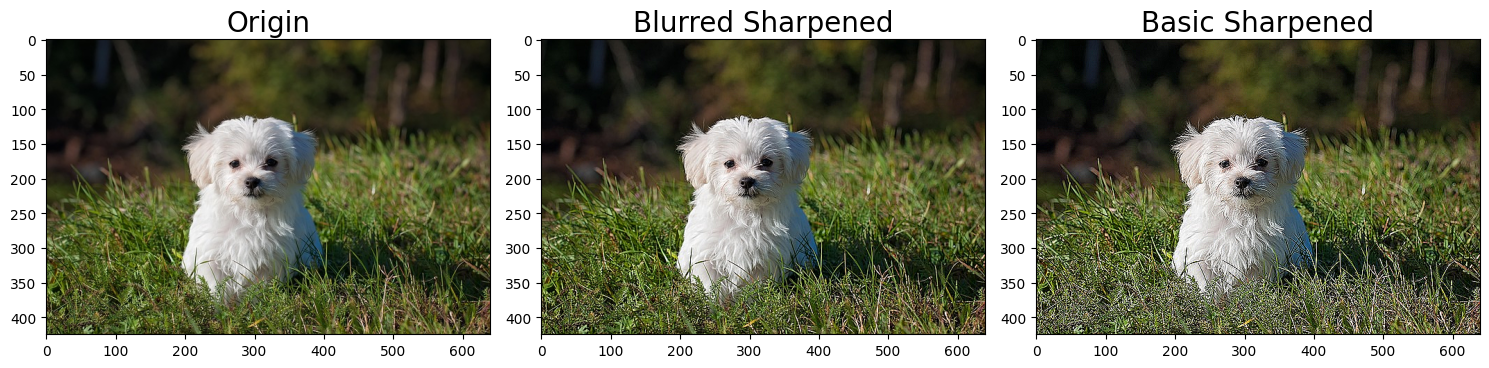

In [5]:
# 讀取影像
img = cv2.imread('sample/dog.jpg')

# 1. 產生高斯模糊影像
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# 2. 透過加權組合實現銳化 (公式：銳化 = 2.0 * 原圖 - 1.0 * 模糊圖)
# 此處 alpha=2.0, beta=-1.0, gamma=0
blurred_sharpened = cv2.addWeighted(img, 2.0, blurred, -1.0, 0)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Origin', img,
    'Blurred Sharpened', blurred_sharpened,
    'Basic Sharpened', sharpened_img
)


### 7-4-1 程式範例：影像馬賽克

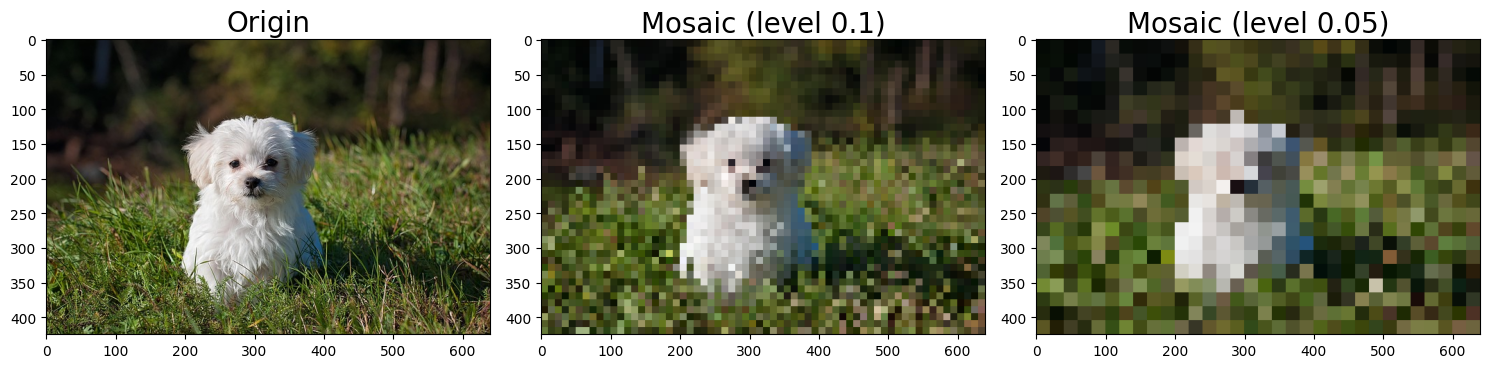

In [6]:
# 讀取影像
img = cv2.imread('sample/dog.jpg')

def mosaic(img, level):
    h, w = img.shape[:2]
    
    # 2. 縮小影像：捨棄大部分的像素資訊
    temp = cv2.resize(img, (int(w * level), int(h * level)), interpolation=cv2.INTER_LINEAR)
    
    # 3. 放大影像：使用最近鄰插值法 (INTER_NEAREST) 產生方塊感
    mosaic_img = cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

    return mosaic_img

# 1. 設定縮放倍率 level（數值越小，方塊越大，馬賽克效果越強）
mosaic_img_0_1 = mosaic(img, 0.1)
mosaic_img_0_0_5 = mosaic(img, 0.05)

# 顯示結果
opencv_tools.show_img_by_matplotlib_1x3(
    'Origin', img,
    'Mosaic (level 0.1)', mosaic_img_0_1,
    'Mosaic (level 0.05)', mosaic_img_0_0_5,
)

### 7-E-2 程式範例：保護貓貓肖像權

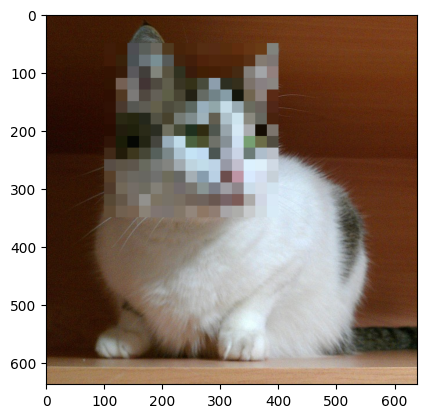

In [7]:
img = cv2.imread('sample/cat.jpg')

# 1. 取出局部區域：定義要處理的局部區域 (ROI) 座標
pt1 = (100, 50)  # 左上角 (x, y)
pt2 = (400, 350) # 右下角 (x, y)
roi = img[pt1[1]:pt2[1], pt1[0]:pt2[0]]

# 2. 對局部區域進行馬賽克處理 (縮小再放大)
level = 0.05 # 縮放倍率，數值越小馬賽克方塊越大
h, w = roi.shape[:2]
temp = cv2.resize(roi, (int(w * level), int(h * level)), interpolation=cv2.INTER_LINEAR)
roi_mosaic = cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

# 3. 將處理後的馬賽克區域放回原圖
img[pt1[1]:pt2[1], pt1[0]:pt2[0]] = roi_mosaic

# 顯示結果
opencv_tools.show_img_by_matplotlib(img)